In [41]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel(r"C:\Users\ashim\NIPT_TEST\nipt_synthetic_dataset.xlsx", sheet_name="Synthetic_NIPT_Data")


In [18]:
df.head()

,sample_id,label,fetal_sex_karyotype,FF_percent,GC_content_percent,total_read_count,chr13_read_count,chr18_read_count,chr21_read_count,chrX_read_count,chrY_read_count
0,S0001,T21,XX,4.71,41.210,3000000,107986,77798,46266,143610,0
1,S0002,Normal,XY,8.24,41.475,3000000,108637,76699,45415,144890,768
2,S0003,Normal,XX,10.95,40.888,3000000,109251,77017,45480,139533,0
3,S0004,XO,X0,14.12,42.036,3000000,110035,76963,45154,132986,0
4,S0005,Normal,XX,11.61,40.704,3000000,108622,78336,45209,144032,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sample_id            1000 non-null   object 
 1   label                1000 non-null   object 
 2   fetal_sex_karyotype  1000 non-null   object 
 3   FF_percent           1000 non-null   float64
 4   GC_content_percent   1000 non-null   float64
 5   total_read_count     1000 non-null   int64  
 6   chr13_read_count     1000 non-null   int64  
 7   chr18_read_count     1000 non-null   int64  
 8   chr21_read_count     1000 non-null   int64  
 9   chrX_read_count      1000 non-null   int64  
 10  chrY_read_count      1000 non-null   int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 86.1+ KB


In [74]:
df.isnull().sum()

sample_id              0
label                  0
fetal_sex_karyotype    0
FF_percent             0
GC_content_percent     0
total_read_count       0
chr13_read_count       0
chr18_read_count       0
chr21_read_count       0
chrX_read_count        0
chrY_read_count        0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(0)

In [23]:
df['fetal_sex_karyotype'].value_counts()

fetal_sex_karyotype
XX     475
XY     325
X0      50
XXY     50
XXX     50
XYY     50
Name: count, dtype: int64

In [25]:
df['label'].value_counts()

label
Normal    650
T21        50
XO         50
XXY        50
XXX        50
T13        50
T18        50
XYY        50
Name: count, dtype: int64

In [77]:
# only Normal and T21 rows keep
data = df[df["label"].isin(["Normal", "T21"])].copy()

In [7]:
# create a new column: 1 if T21, 0 if Normal
data["is_t21"] = (data["label"] == "T21").astype(int)

print(data["is_t21"].value_counts())
data[["label", "is_t21", "chr21_read_count", "FF_percent", "GC_content_percent"]].head()

is_t21
0    650
1     50
Name: count, dtype: int64


,label,is_t21,chr21_read_count,FF_percent,GC_content_percent
0,T21,1,46266,4.71,41.210
1,Normal,0,45415,8.24,41.475
2,Normal,0,45480,10.95,40.888
4,Normal,0,45209,11.61,40.704
5,Normal,0,45382,8.81,41.926


In [28]:
from sklearn.model_selection import train_test_split

X = data[["chr21_read_count", "FF_percent", "GC_content_percent"]]
y = data["is_t21"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [30]:
#Train and test sample
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 525
Testing samples: 175


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [35]:
#Training the Model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Feature weights (chr21_read_count, FF, GC):", model.coef_[0])

Feature weights (chr21_read_count, FF, GC): [ 2.92873849 -1.21711662 -0.38831717]


In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc, 3))

Accuracy: 0.983


In [38]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)


Confusion matrix:
[[162   1]
 [  2  10]]


In [39]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
ppv = tp / (tp + fp)

print(f"Sensitivity: {sensitivity:.2%}  (how many real T21 cases we caught)")
print(f"PPV:         {ppv:.2%}  (how many of our T21 flags were actually correct)")

Sensitivity: 83.33%  (how many real T21 cases we caught)
PPV:         90.91%  (how many of our T21 flags were actually correct)


USING MATPLOTLIB FOR PLOTTING TASK.. NOTE: WE CALLED MATPLOTLIB ABOVE

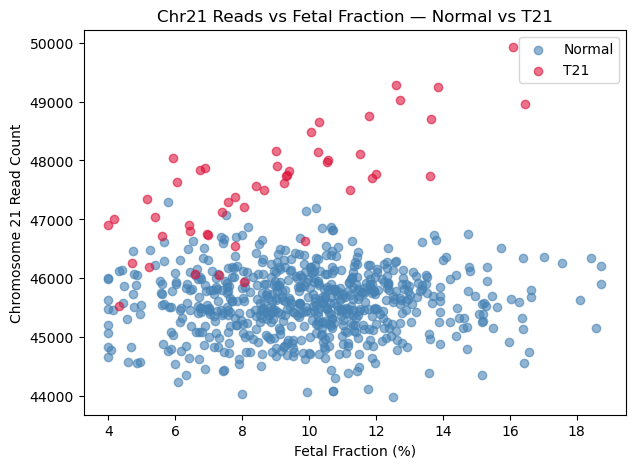

In [40]:

plt.figure(figsize=(7, 5))
colors = {"Normal": "steelblue", "T21": "crimson"}
for label, group in data.groupby("label"):
    plt.scatter(group["FF_percent"], group["chr21_read_count"],
                label=label, alpha=0.6, color=colors[label])

plt.xlabel("Fetal Fraction (%)")
plt.ylabel("Chromosome 21 Read Count")
plt.title("Chr21 Reads vs Fetal Fraction — Normal vs T21")
plt.legend()
plt.show()


Histogram Insertation

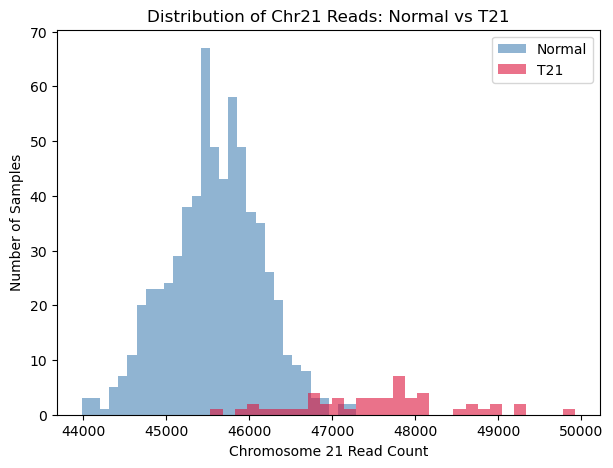

In [42]:
plt.figure(figsize=(7, 5))
plt.hist(data[data["label"]=="Normal"]["chr21_read_count"], bins=30, alpha=0.6, label="Normal", color="steelblue")
plt.hist(data[data["label"]=="T21"]["chr21_read_count"], bins=30, alpha=0.6, label="T21", color="crimson")
plt.xlabel("Chromosome 21 Read Count")
plt.ylabel("Number of Samples")
plt.title("Distribution of Chr21 Reads: Normal vs T21")
plt.legend()
plt.show()

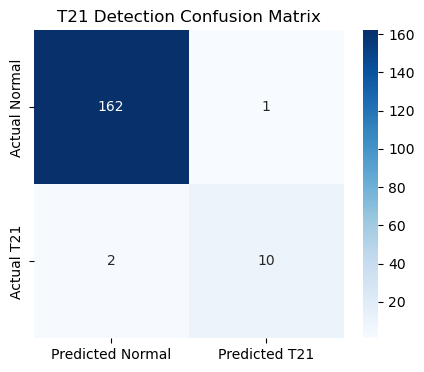

In [44]:
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Normal", "Predicted T21"],
            yticklabels=["Actual Normal", "Actual T21"])
plt.title("T21 Detection Confusion Matrix")
plt.show()

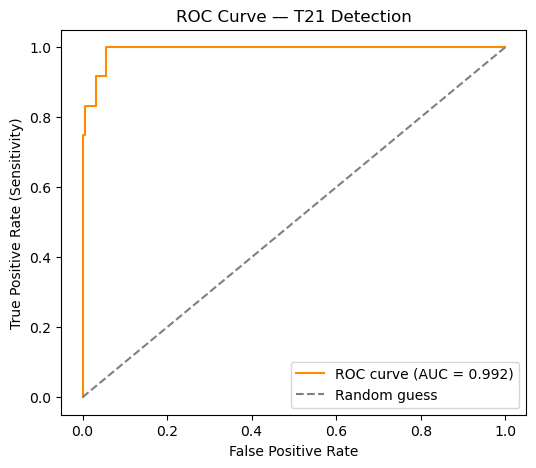

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — T21 Detection")
plt.legend()
plt.show()

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate_trisomy(df, trisomy_label, chrom_col):
    subset = df[df["label"].isin(["Normal", trisomy_label])].copy()
    subset["y"] = (subset["label"] == trisomy_label).astype(int)
    X = subset[[chrom_col, "FF_percent", "GC_content_percent"]]
    y = subset["y"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    model = LogisticRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    ppv = tp / (tp + fp) if (tp + fp) else float("nan")
    accuracy = accuracy_score(y_test, y_pred)
    return {
        "Trisomy": trisomy_label,
        "Test size": len(y_test),
        "Accuracy": round(accuracy, 3),
        "Sensitivity": round(sensitivity, 3),
        "PPV": round(ppv, 3),
    }

In [73]:
results = [
    evaluate_trisomy(df, "T13", "chr13_read_count"),
    evaluate_trisomy(df, "T18", "chr18_read_count"),
    evaluate_trisomy(df, "T21", "chr21_read_count"),
]
summary = pd.DataFrame(results)
print(summary)

  Trisomy  Test size  Accuracy  Sensitivity    PPV
0     T13        175     0.983        0.833  0.909
1     T18        175     0.989        0.833  1.000
2     T21        175     0.983        0.833  0.909


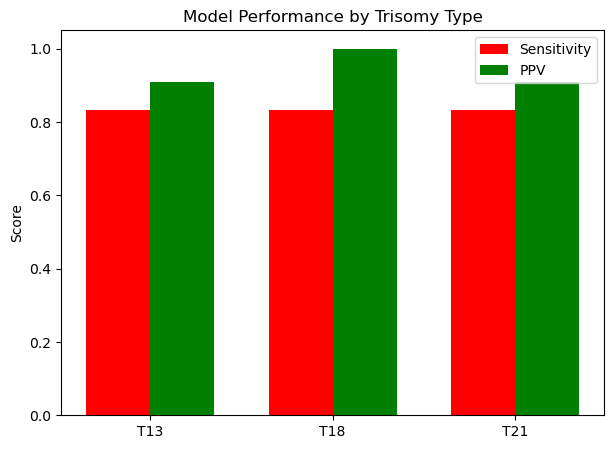

In [52]:
x = range(len(summary))
width = 0.35
plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], summary["Sensitivity"], width, label="Sensitivity", color="red")
plt.bar([i + width/2 for i in x], summary["PPV"], width, label="PPV", color="green")
plt.xticks(list(x), summary["Trisomy"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance by Trisomy Type")
plt.legend()
plt.show()